# Multi-Criteria Dynamic Route Optimization

## Hybrid Approach: AHP + Gini + alpha-Hurwicz + Dijkstra
### Domain: Urban Road Navigation

---
**Team Memebers**:
- Harzelli Abd El Mounaim
- Kasbadji Mohamed Halim
- Kayouche Ahmed Samy
- Kendel Najib

**Objective**: Improve the simple Shortest Path Algorithm (Dijkstra) using a 5-step decision-making pipeline that handles multiple criteria and uncertainty.

**4 Approaches Compared**:
1. Plain Dijkstra (baseline, distance only)
2. AHP + alpha-Hurwicz + Dijkstra (expert weights + uncertainty)
3. Gini + alpha-Hurwicz + Dijkstra (data-driven weights + uncertainty)
4. AHP + Gini + alpha-Hurwicz + Dijkstra (full pipeline)

## Setup and Imports

In [1]:
import sys, os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import heapq
import time
import math
from tabulate import tabulate

%matplotlib inline
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 120,
    "figure.figsize": (12, 6),
})

print("All imports successful")

All imports successful


## Domain Definition: Urban Road Navigation

We model an urban road network where each road segment (edge) has 4 criteria, each with an uncertainty interval [x_min, x_max]:

| Criterion | What it measures | Unit | Uncertainty Level |
|-----------|-----------------|------|-------------------|
| Distance | Road length | km | Low |
| Travel Time | Drive duration | minutes | Moderate |
| Safety Risk | Accident probability | 0-1 | High |
| Congestion | Traffic jam level | 0-1 | High |

In [2]:
CRITERIA = ["distance", "travel_time", "safety_risk", "congestion"]
NUM_CRITERIA = len(CRITERIA)
print(f"Number of criteria: {NUM_CRITERIA}")
print(f"Criteria: {CRITERIA}")

Number of criteria: 4
Criteria: ['distance', 'travel_time', 'safety_risk', 'congestion']


## Graph Generation

We generate a random directed urban road graph where:
- Nodes = intersections placed randomly on a 2D plane
- Edges = road segments with multi-criteria attributes
- Each edge has interval-valued data [x_min, x_max] for every criterion

In [3]:
def euclidean(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def generate_edge_criteria(euclidean_dist, rng):
    base_dist = euclidean_dist / 10.0
    dist_min = base_dist * rng.uniform(0.95, 1.0)
    dist_max = base_dist * rng.uniform(1.0, 1.05)

    speed = rng.uniform(30, 60)
    base_time = (base_dist / speed) * 60
    time_min = base_time * rng.uniform(0.8, 1.0)
    time_max = base_time * rng.uniform(1.0, 1.5)

    base_risk = rng.beta(2, 5)
    risk_min = max(0.0, base_risk * rng.uniform(0.5, 0.9))
    risk_max = min(1.0, base_risk * rng.uniform(1.1, 2.0))

    base_cong = rng.beta(2, 3)
    cong_min = max(0.0, base_cong * rng.uniform(0.4, 0.8))
    cong_max = min(1.0, base_cong * rng.uniform(1.2, 2.5))

    return {
        "distance_min": dist_min, "distance_max": dist_max,
        "travel_time_min": time_min, "travel_time_max": time_max,
        "safety_risk_min": risk_min, "safety_risk_max": risk_max,
        "congestion_min": cong_min, "congestion_max": cong_max,
        "weight": (dist_min + dist_max) / 2.0,
    }

def generate_urban_graph(n_nodes, connectivity=0.3, seed=42):
    rng = np.random.RandomState(seed)
    positions = {i: (rng.uniform(0, 100), rng.uniform(0, 100)) for i in range(n_nodes)}

    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))
    nx.set_node_attributes(G, positions, "pos")

    for i in range(n_nodes):
        for j in range(n_nodes):
            if i != j and rng.random() < connectivity:
                dist = euclidean(positions[i], positions[j])
                G.add_edge(i, j, **generate_edge_criteria(dist, rng))

    if not nx.is_strongly_connected(G):
        components = list(nx.strongly_connected_components(G))
        for idx in range(len(components) - 1):
            c1, c2 = list(components[idx])[:5], list(components[idx+1])[:5]
            best = min(((u,v) for u in c1 for v in c2), key=lambda p: euclidean(positions[p[0]], positions[p[1]]))
            for a, b in [best, (best[1], best[0])]:
                if not G.has_edge(a, b):
                    G.add_edge(a, b, **generate_edge_criteria(euclidean(positions[a], positions[b]), rng))
    return G

def generate_scaled_graph(n_nodes, avg_degree=6, seed=42):
    rng = np.random.RandomState(seed)
    positions = {i: (rng.uniform(0, 100), rng.uniform(0, 100)) for i in range(n_nodes)}
    G = nx.DiGraph()
    G.add_nodes_from(range(n_nodes))
    nx.set_node_attributes(G, positions, "pos")

    for i in range(n_nodes):
        dists = sorted([(j, euclidean(positions[i], positions[j])) for j in range(n_nodes) if j != i], key=lambda x: x[1])
        n_near = max(1, avg_degree // 2)
        n_rand = max(1, avg_degree - n_near)
        neighbours = [x[0] for x in dists[:n_near]]
        remaining = [x[0] for x in dists[n_near:]]
        if remaining:
            neighbours += list(rng.choice(remaining, size=min(n_rand, len(remaining)), replace=False))
        for j in neighbours:
            if not G.has_edge(i, j):
                G.add_edge(i, j, **generate_edge_criteria(euclidean(positions[i], positions[j]), rng))

    if not nx.is_strongly_connected(G):
        components = list(nx.strongly_connected_components(G))
        for idx in range(len(components) - 1):
            c1, c2 = list(components[idx])[:5], list(components[idx+1])[:5]
            best = min(((u,v) for u in c1 for v in c2), key=lambda p: euclidean(positions[p[0]], positions[p[1]]))
            for a, b in [best, (best[1], best[0])]:
                if not G.has_edge(a, b):
                    G.add_edge(a, b, **generate_edge_criteria(euclidean(positions[a], positions[b]), rng))
    return G

print("Graph generator ready")

Graph generator ready


### Generate Demo Graph

In [4]:
N_NODES = 40
CONNECTIVITY = 0.15
SEED = 42
SOURCE = 0
TARGET = N_NODES - 1

G = generate_urban_graph(N_NODES, connectivity=CONNECTIVITY, seed=SEED)

print(f"Graph Statistics:")
print(f"   Nodes (|V|):          {G.number_of_nodes()}")
print(f"   Edges (|E|):          {G.number_of_edges()}")
print(f"   Density:              {nx.density(G):.4f}")
print(f"   Strongly connected:   {nx.is_strongly_connected(G)}")
print(f"   Avg out-degree:       {sum(d for _, d in G.out_degree()) / G.number_of_nodes():.1f}")
print(f"   Source -> Target:     {SOURCE} -> {TARGET}")

Graph Statistics:
   Nodes (|V|):          40
   Edges (|E|):          264
   Density:              0.1692
   Strongly connected:   True
   Avg out-degree:       6.6
   Source -> Target:     0 -> 39


---

## Step 1: Subjective Weighting (AHP)

The Analytic Hierarchy Process lets a human expert rank the importance of each criterion using pairwise comparisons on Saaty's 1-9 scale.

Our profile: A safety-conscious driver who prioritizes Safety Risk > Travel Time > Distance > Congestion.

In [5]:
RANDOM_INDEX = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.90, 5: 1.12, 6: 1.24, 7: 1.32}

def ahp_weights(comparison_matrix):
    n = comparison_matrix.shape[0]
    eigenvalues, eigenvectors = np.linalg.eig(comparison_matrix)

    max_idx = np.argmax(eigenvalues.real)
    lambda_max = eigenvalues.real[max_idx]

    principal = np.abs(eigenvectors[:, max_idx].real)
    weights = principal / principal.sum()

    ci = (lambda_max - n) / (n - 1) if n > 1 else 0.0
    ri = RANDOM_INDEX.get(n, 1.49)
    cr = ci / ri if ri > 0 else 0.0

    return weights, lambda_max, ci, cr, cr < 0.10

A = np.array([
    [1,     1/3,  1/5,    3   ],
    [3,     1,    1/3,    5   ],
    [5,     3,    1,      7   ],
    [1/3,   1/5,  1/7,    1   ],
], dtype=float)

Ws, lambda_max, ci, cr, is_consistent = ahp_weights(A)

print("=" * 60)
print("  STEP 1: AHP -- Subjective Weighting")
print("=" * 60)
print(f"\n  Comparison Matrix:")
print(f"  {A}")
print(f"\n  lambda_max = {lambda_max:.4f}")
print(f"  Consistency Index (CI) = {ci:.4f}")
print(f"  Consistency Ratio (CR) = {cr:.4f}  {'Consistent' if is_consistent else 'INCONSISTENT'}")
print(f"\n  Subjective Weight Vector (Ws):")
for i, c in enumerate(CRITERIA):
    bar = "|" * int(Ws[i] * 40)
    print(f"     {c:15s}: {Ws[i]:.4f}  {bar}")

  STEP 1: AHP -- Subjective Weighting

  Comparison Matrix:
  [[1.         0.33333333 0.2        3.        ]
 [3.         1.         0.33333333 5.        ]
 [5.         3.         1.         7.        ]
 [0.33333333 0.2        0.14285714 1.        ]]

  lambda_max = 4.1170
  Consistency Index (CI) = 0.0390
  Consistency Ratio (CR) = 0.0433  Consistent

  Subjective Weight Vector (Ws):
     distance       : 0.1175  ||||
     travel_time    : 0.2622  ||||||||||
     safety_risk    : 0.5650  ||||||||||||||||||||||
     congestion     : 0.0553  ||


### Visualize AHP Weights

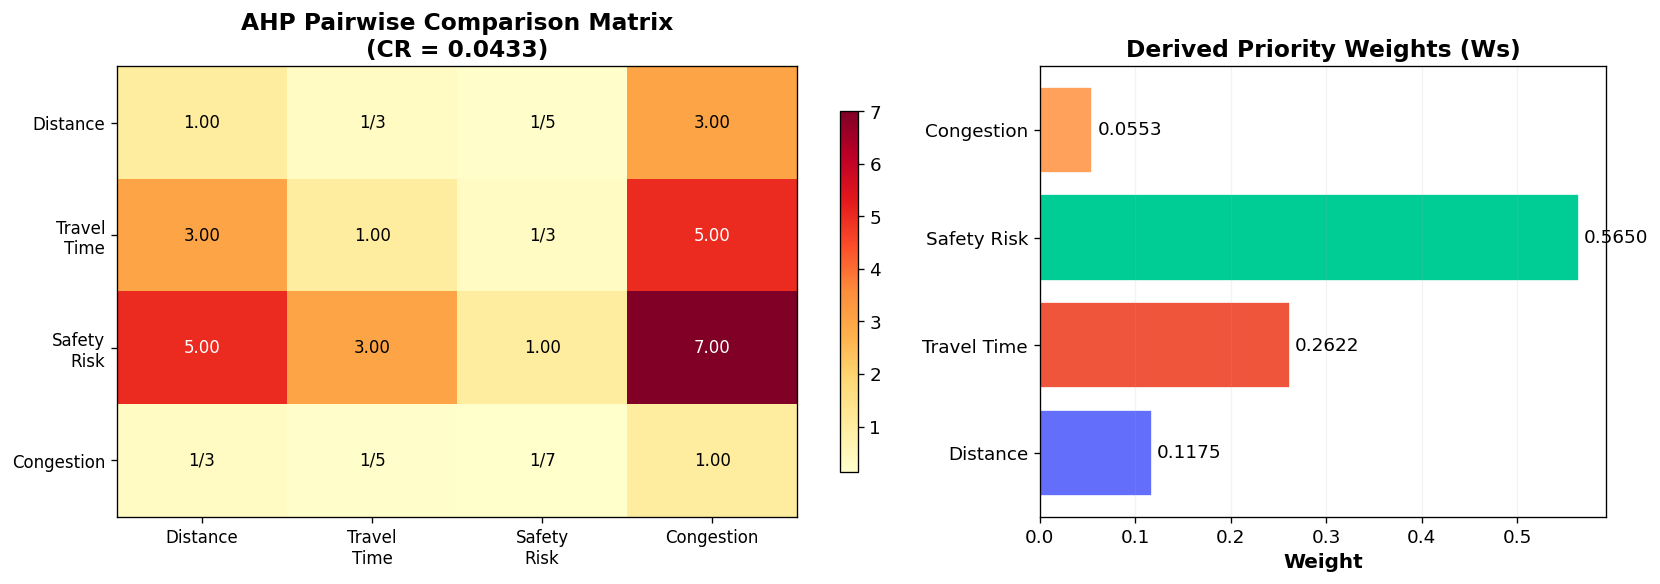

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.5, 1]})

ax = axes[0]
labels = [c.replace("_", "\n").title() for c in CRITERIA]
im = ax.imshow(A, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(labels, fontsize=10); ax.set_yticklabels(labels, fontsize=10)
for i in range(4):
    for j in range(4):
        val = A[i][j]
        text = f"{val:.2f}" if val >= 1 else f"1/{1/val:.0f}"
        ax.text(j, i, text, ha="center", va="center", fontsize=10, color="white" if val > 3 else "black")
ax.set_title(f"AHP Pairwise Comparison Matrix\n(CR = {cr:.4f})", fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8)

ax = axes[1]
colors = ["#636EFA", "#EF553B", "#00CC96", "#FFA15A"]
bars = ax.barh(range(4), Ws, color=colors, edgecolor="white")
ax.set_yticks(range(4))
ax.set_yticklabels([c.replace("_", " ").title() for c in CRITERIA])
ax.set_xlabel("Weight", fontweight="bold")
ax.set_title("Derived Priority Weights (Ws)", fontweight="bold")
for bar, w in zip(bars, Ws):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2., f"{w:.4f}", va="center", fontsize=11)
ax.grid(True, alpha=0.15, axis="x")

fig.tight_layout()
plt.show()

---

## Step 2: Objective Weighting (Gini Index)

The Gini coefficient measures inequality/dispersion in the data. Higher Gini = more variance = more discriminating power = higher weight.

- Gini near 0: All edges have similar values (not useful for routing)
- Gini near 1: Huge variance across edges (very informative for routing)

In [7]:
def gini_coefficient(values):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    if n == 0 or values.sum() == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return max(0.0, (2.0 * np.sum(index * values)) / (n * values.sum()) - (n + 1.0) / n)

def compute_gini_weights(G):
    edges = list(G.edges(data=True))
    gini_values = []

    for criterion in CRITERIA:
        midpoints = np.array([(d[f"{criterion}_min"] + d[f"{criterion}_max"]) / 2.0 for _, _, d in edges])
        gini_values.append(gini_coefficient(midpoints))

    gini_values = np.array(gini_values)
    total = gini_values.sum()
    weights = gini_values / total if total > 0 else np.ones(NUM_CRITERIA) / NUM_CRITERIA
    return weights, gini_values

Wo, gini_vals = compute_gini_weights(G)

print("=" * 60)
print("  STEP 2: Gini Index -- Objective Weighting")
print("=" * 60)
print(f"\n  Criterion          Gini Coeff    Objective Weight (Wo)")
print(f"  {'-'*55}")
for i, c in enumerate(CRITERIA):
    bar = "|" * int(Wo[i] * 40)
    print(f"  {c:15s}    {gini_vals[i]:.4f}         {Wo[i]:.4f}  {bar}")
print(f"\n  Sum of weights: {Wo.sum():.4f}")

  STEP 2: Gini Index -- Objective Weighting

  Criterion          Gini Coeff    Objective Weight (Wo)
  -------------------------------------------------------
  distance           0.2900         0.2480  |||||||||
  travel_time        0.3226         0.2759  |||||||||||
  safety_risk        0.2816         0.2408  |||||||||
  congestion         0.2751         0.2353  |||||||||

  Sum of weights: 1.0000


---

## Step 3: Weight Fusion

We blend the subjective (AHP) and objective (Gini) weight vectors using a coefficient beta:

W = beta * Ws + (1 - beta) * Wo

- beta = 1: Trust the expert completely (AHP only)
- beta = 0: Trust the data completely (Gini only)
- beta = 0.5: Equal blend of both

In [8]:
BETA = 0.5

W = BETA * Ws + (1 - BETA) * Wo
W = W / W.sum()

print("=" * 60)
print(f"  STEP 3: Weight Fusion (beta = {BETA})")
print("=" * 60)
print(f"\n  Criterion          Ws (AHP)    Wo (Gini)   W (Fused)")
print(f"  {'-'*55}")
for i, c in enumerate(CRITERIA):
    print(f"  {c:15s}    {Ws[i]:.4f}      {Wo[i]:.4f}      {W[i]:.4f}")
print(f"\n  Sum: {W.sum():.4f}")

  STEP 3: Weight Fusion (beta = 0.5)

  Criterion          Ws (AHP)    Wo (Gini)   W (Fused)
  -------------------------------------------------------
  distance           0.1175      0.2480      0.1828
  travel_time        0.2622      0.2759      0.2690
  safety_risk        0.5650      0.2408      0.4029
  congestion         0.0553      0.2353      0.1453

  Sum: 1.0000


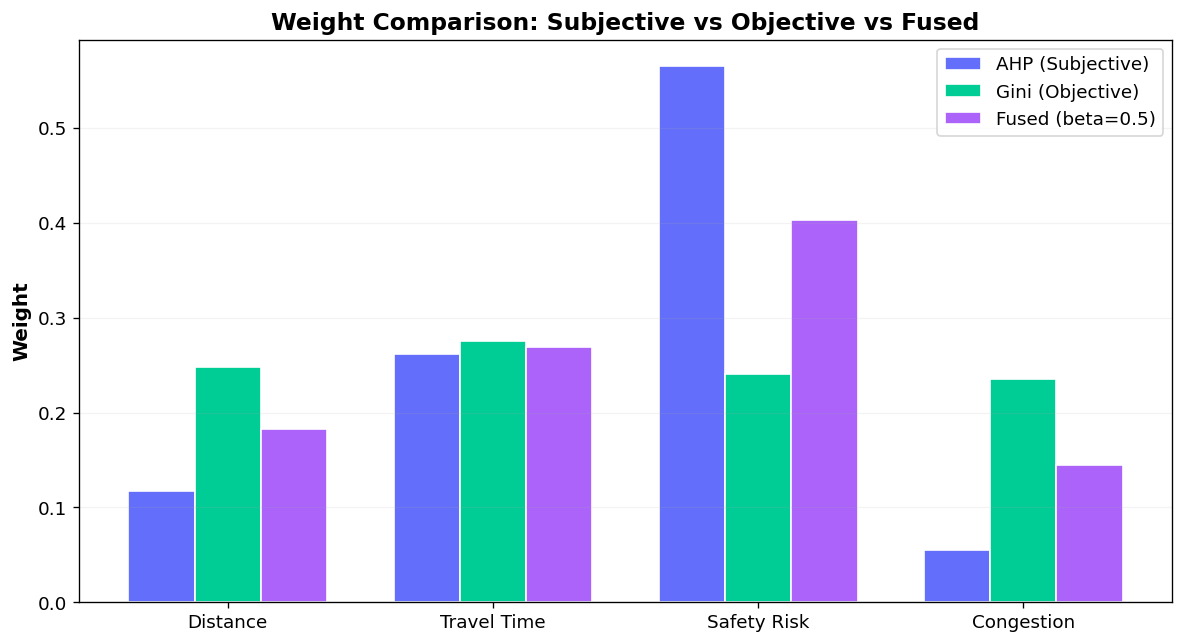

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(NUM_CRITERIA)
width = 0.25

ax.bar(x - width, Ws, width, label="AHP (Subjective)", color="#636EFA", edgecolor="white")
ax.bar(x, Wo, width, label="Gini (Objective)", color="#00CC96", edgecolor="white")
ax.bar(x + width, W, width, label=f"Fused (beta={BETA})", color="#AB63FA", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_", " ").title() for c in CRITERIA])
ax.set_ylabel("Weight", fontweight="bold")
ax.set_title("Weight Comparison: Subjective vs Objective vs Fused", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.15, axis="y")
plt.tight_layout()
plt.show()

---

## Step 4: Risk Resolution (alpha-Hurwicz)

Each edge has uncertain values [x_min, x_max]. The Hurwicz criterion resolves this:

V = alpha * x_min + (1 - alpha) * x_max

- alpha = 1: Fully optimistic (best case)
- alpha = 0: Fully pessimistic (worst case)
- alpha = 0.5: Balanced

In [10]:
ALPHA = 0.5

def hurwicz_value(x_min, x_max, alpha):
    return alpha * x_min + (1 - alpha) * x_max

if G.has_edge(0, 1):
    data = G[0][1]
    print("=" * 60)
    print(f"  STEP 4: alpha-Hurwicz Risk Resolution (alpha = {ALPHA})")
    print("=" * 60)
    print(f"\n  Example edge: 0 -> 1")
    print(f"  {'Criterion':15s}  {'x_min':>8s}  {'x_max':>8s}  {'V (Hurwicz)':>12s}")
    print(f"  {'-'*48}")
    for c in CRITERIA:
        xmin = data[f"{c}_min"]
        xmax = data[f"{c}_max"]
        v = hurwicz_value(xmin, xmax, ALPHA)
        print(f"  {c:15s}  {xmin:8.4f}  {xmax:8.4f}  {v:12.4f}")

---

## Step 5: Cost Calculation and Dijkstra Optimization

For every edge, we compute a single composite cost:

C_ij = sum(wk * V_ij_k) for k = 1 to n criteria

Then Dijkstra's Algorithm finds the path with minimum total cost.

In [11]:
def compute_edge_cost(edge_data, weights, alpha):
    V = np.array([hurwicz_value(edge_data[f"{c}_min"], edge_data[f"{c}_max"], alpha) for c in CRITERIA])
    return float(np.dot(weights, V))

def dijkstra_multicriteria(G, source, target, weights, alpha):
    dist = {node: float("inf") for node in G.nodes()}
    prev = {node: None for node in G.nodes()}
    dist[source] = 0.0
    pq = [(0.0, source)]
    visited = set()

    while pq:
        d, u = heapq.heappop(pq)
        if u in visited: continue
        visited.add(u)
        if u == target: break
        for v in G.successors(u):
            if v in visited: continue
            cost = compute_edge_cost(G[u][v], weights, alpha)
            new_dist = dist[u] + cost
            if new_dist < dist[v]:
                dist[v] = new_dist
                prev[v] = u
                heapq.heappush(pq, (new_dist, v))

    path = []
    node = target
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return (path, dist[target]) if path[0] == source else ([], float("inf"))

def dijkstra_simple(G, source, target):
    dist = {node: float("inf") for node in G.nodes()}
    prev = {node: None for node in G.nodes()}
    dist[source] = 0.0
    pq = [(0.0, source)]
    visited = set()

    while pq:
        d, u = heapq.heappop(pq)
        if u in visited: continue
        visited.add(u)
        if u == target: break
        for v in G.successors(u):
            if v in visited: continue
            new_dist = dist[u] + G[u][v]["weight"]
            if new_dist < dist[v]:
                dist[v] = new_dist
                prev[v] = u
                heapq.heappush(pq, (new_dist, v))

    path = []
    node = target
    while node is not None:
        path.append(node)
        node = prev[node]
    path.reverse()
    return (path, dist[target]) if path[0] == source else ([], float("inf"))

def path_criterion_totals(G, path, alpha):
    totals = {c: 0.0 for c in CRITERIA}
    for i in range(len(path)-1):
        data = G[path[i]][path[i+1]]
        for c in CRITERIA:
            totals[c] += (data[f"{c}_min"] + data[f"{c}_max"]) / 2.0
    return totals

print("Dijkstra implementations ready")

Dijkstra implementations ready


---

## Comparative Analysis: All 4 Approaches

In [12]:
print("=" * 70)
print("  COMPARATIVE ANALYSIS -- 4 APPROACHES")
print(f"  Graph: |V|={G.number_of_nodes()}, |E|={G.number_of_edges()}")
print(f"  Route: {SOURCE} -> {TARGET},  alpha={ALPHA},  beta={BETA}")
print("=" * 70)

results = {}

t0 = time.perf_counter()
p1, c1 = dijkstra_simple(G, SOURCE, TARGET)
t1 = time.perf_counter()
results["Dijkstra"] = {"path": p1, "cost": c1, "time": (t1-t0)*1000, "details": path_criterion_totals(G, p1, ALPHA)}

t0 = time.perf_counter()
p2, c2 = dijkstra_multicriteria(G, SOURCE, TARGET, Ws, ALPHA)
t1 = time.perf_counter()
results["AHP+Hurwicz+Dijkstra"] = {"path": p2, "cost": c2, "time": (t1-t0)*1000, "details": path_criterion_totals(G, p2, ALPHA)}

t0 = time.perf_counter()
p3, c3 = dijkstra_multicriteria(G, SOURCE, TARGET, Wo, ALPHA)
t1 = time.perf_counter()
results["Gini+Hurwicz+Dijkstra"] = {"path": p3, "cost": c3, "time": (t1-t0)*1000, "details": path_criterion_totals(G, p3, ALPHA)}

t0 = time.perf_counter()
p4, c4 = dijkstra_multicriteria(G, SOURCE, TARGET, W, ALPHA)
t1 = time.perf_counter()
results["AHP+Gini+Hurwicz+Dijkstra"] = {"path": p4, "cost": c4, "time": (t1-t0)*1000, "details": path_criterion_totals(G, p4, ALPHA)}

rows = []
for name, r in results.items():
    path_str = "->".join(map(str, r["path"]))
    rows.append([name, path_str, len(r["path"])-1, f"{r['cost']:.4f}", f"{r['time']:.3f}"])

print("\n" + tabulate(rows, headers=["Approach", "Path", "Edges", "Cost", "Time (ms)"], tablefmt="fancy_grid"))

print("\n  Per-Criterion Totals Along Each Path:")
crit_rows = []
for name, r in results.items():
    row = [name] + [f"{r['details'][c]:.3f}" for c in CRITERIA]
    crit_rows.append(row)
print(tabulate(crit_rows, headers=["Approach"] + [c.replace("_"," ").title() for c in CRITERIA], tablefmt="fancy_grid"))

  COMPARATIVE ANALYSIS -- 4 APPROACHES
  Graph: |V|=40, |E|=264
  Route: 0 -> 39,  alpha=0.5,  beta=0.5

╒═══════════════════════════╤═══════════╤═════════╤════════╤═════════════╕
│ Approach                  │ Path      │   Edges │   Cost │   Time (ms) │
╞═══════════════════════════╪═══════════╪═════════╪════════╪═════════════╡
│ Dijkstra                  │ 0->39     │       1 │ 8.4326 │       0.925 │
├───────────────────────────┼───────────┼─────────┼────────┼─────────────┤
│ AHP+Hurwicz+Dijkstra      │ 0->22->39 │       2 │ 3.78   │       2.001 │
├───────────────────────────┼───────────┼─────────┼────────┼─────────────┤
│ Gini+Hurwicz+Dijkstra     │ 0->22->39 │       2 │ 5.1675 │      16.098 │
├───────────────────────────┼───────────┼─────────┼────────┼─────────────┤
│ AHP+Gini+Hurwicz+Dijkstra │ 0->22->39 │       2 │ 4.4737 │       2.997 │
╘═══════════════════════════╧═══════════╧═════════╧════════╧═════════════╛

  Per-Criterion Totals Along Each Path:
╒═══════════════════════════╤

### Path Visualization on the Network

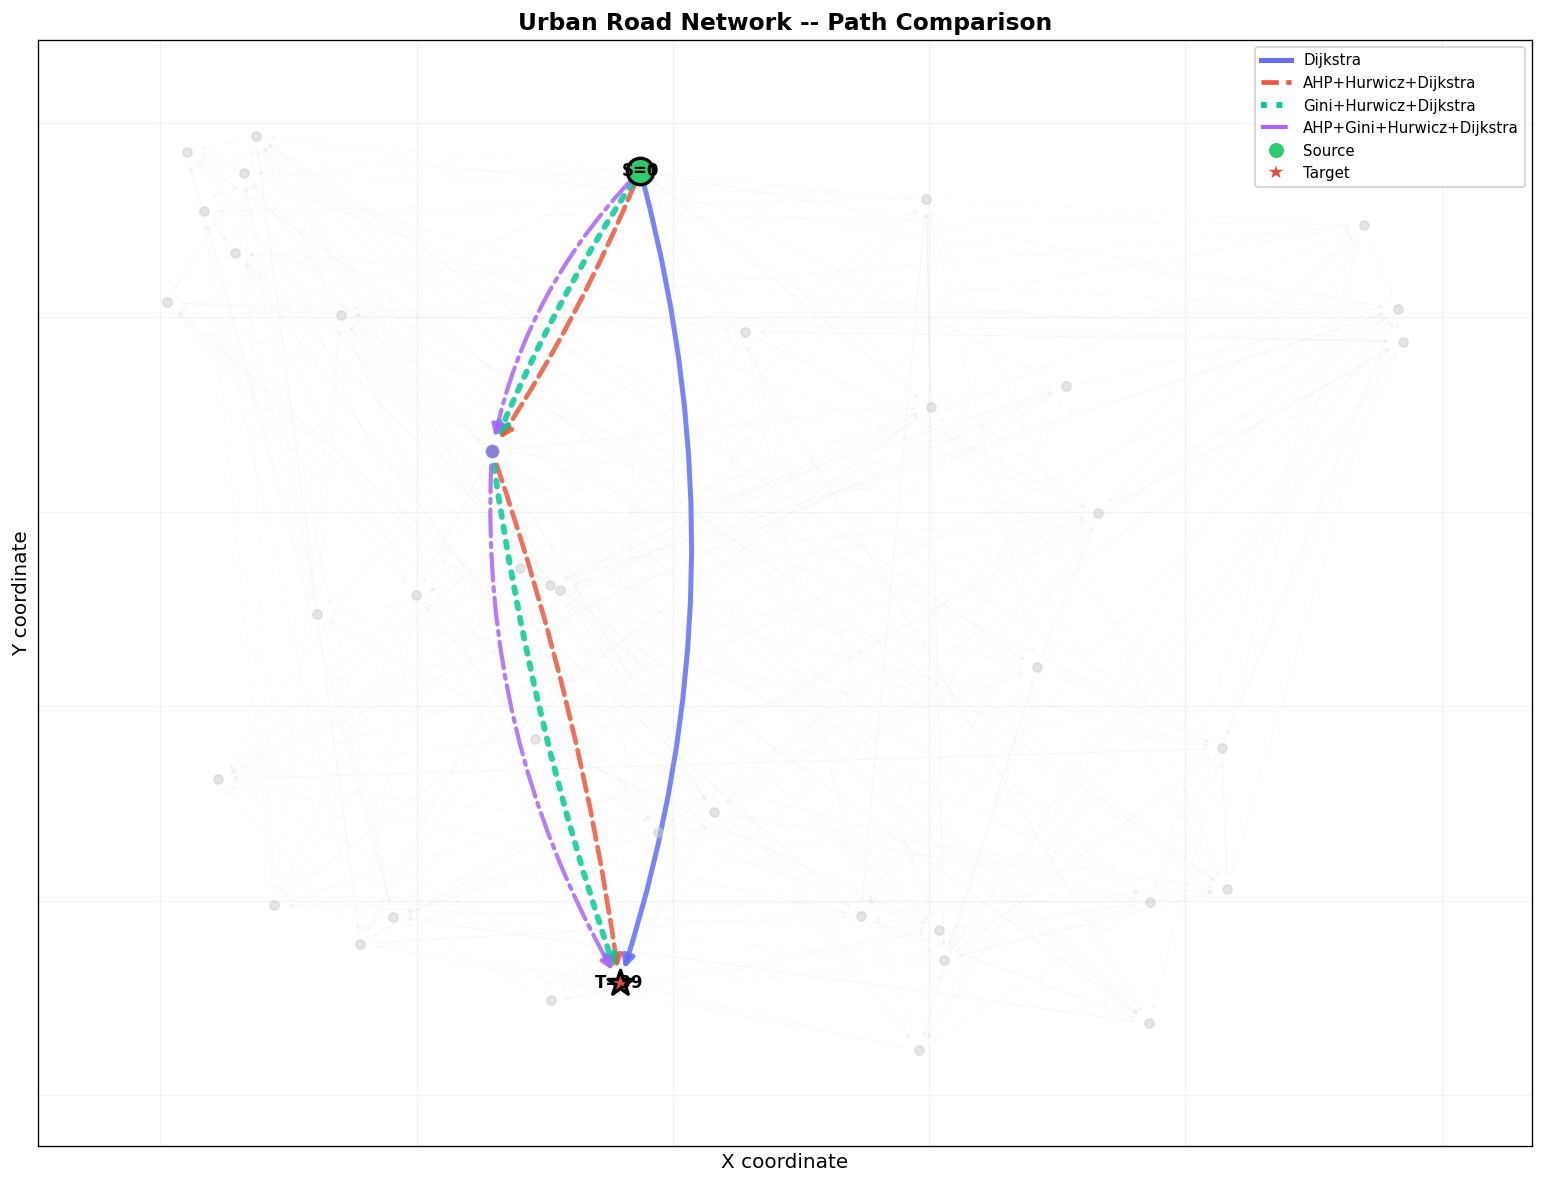

In [13]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(13, 10))
pos = nx.get_node_attributes(G, "pos")

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.08, edge_color="#cccccc", width=0.5, arrows=True, arrowsize=5)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=30, node_color="#cccccc", alpha=0.5)

COLORS = {"Dijkstra": "#636EFA", "AHP+Hurwicz+Dijkstra": "#EF553B",
          "Gini+Hurwicz+Dijkstra": "#00CC96", "AHP+Gini+Hurwicz+Dijkstra": "#AB63FA"}
radii = [-0.15, -0.05, 0.05, 0.15]
styles = ["solid", "dashed", "dotted", "dashdot"]
widths = [3.0, 2.8, 3.5, 2.5]

for idx, (name, r) in enumerate(results.items()):
    path = r["path"]
    if not path or len(path) < 2: continue
    edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
    nx.draw_networkx_edges(G, pos, edgelist=edges, ax=ax, edge_color=COLORS[name],
                           width=widths[idx], alpha=0.85, arrows=True, arrowsize=14,
                           connectionstyle=f"arc3,rad={radii[idx]}", style=styles[idx])
    nx.draw_networkx_nodes(G, pos, nodelist=path, ax=ax, node_size=80,
                           node_color=COLORS[name], alpha=0.65, edgecolors="white")

nx.draw_networkx_nodes(G, pos, nodelist=[SOURCE], ax=ax, node_size=250, node_color="#2ECC71", edgecolors="black", linewidths=2)
nx.draw_networkx_nodes(G, pos, nodelist=[TARGET], ax=ax, node_size=250, node_color="#E74C3C", edgecolors="black", linewidths=2, node_shape="*")
nx.draw_networkx_labels(G, pos, labels={SOURCE: f"S={SOURCE}", TARGET: f"T={TARGET}"}, ax=ax, font_size=10, font_weight="bold")

legend = [Line2D([0],[0], color=COLORS[n], lw=widths[i], linestyle=styles[i], label=n) for i,n in enumerate(COLORS)]
legend += [Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ECC71', markersize=10, label='Source'),
           Line2D([0],[0], marker='*', color='w', markerfacecolor='#E74C3C', markersize=12, label='Target')]
ax.legend(handles=legend, loc="upper right", framealpha=0.9, fontsize=9)
ax.set_title("Urban Road Network -- Path Comparison", fontweight="bold", fontsize=14)
ax.set_xlabel("X coordinate"); ax.set_ylabel("Y coordinate")
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

### Per-Criterion Performance Comparison

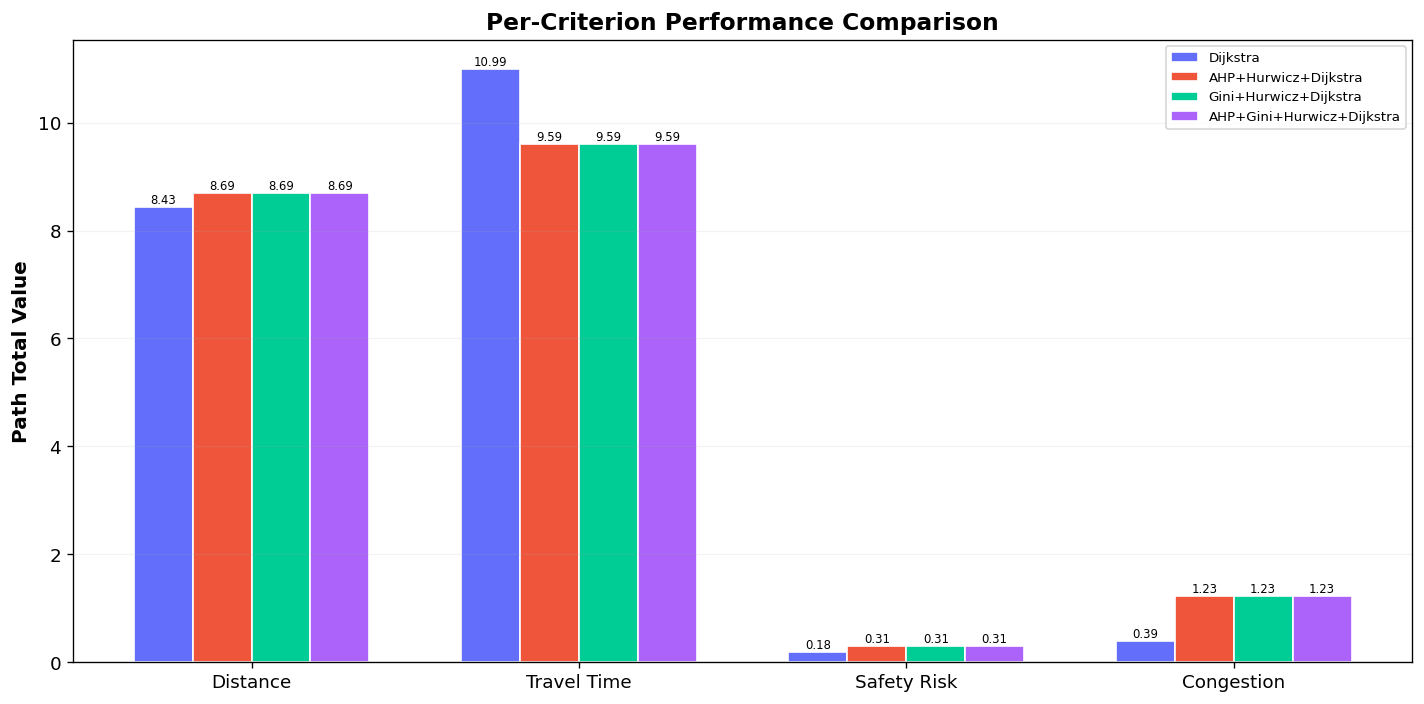

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
approaches = list(results.keys())
x = np.arange(NUM_CRITERIA)
width = 0.18

for idx, name in enumerate(approaches):
    vals = [results[name]["details"][c] for c in CRITERIA]
    offset = (idx - len(approaches)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=name, color=COLORS[name], edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels([c.replace("_"," ").title() for c in CRITERIA])
ax.set_ylabel("Path Total Value", fontweight="bold")
ax.set_title("Per-Criterion Performance Comparison", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.15, axis="y")
plt.tight_layout()
plt.show()

---

## Sensitivity Analysis

### alpha-Hurwicz Sensitivity (optimism vs pessimism)

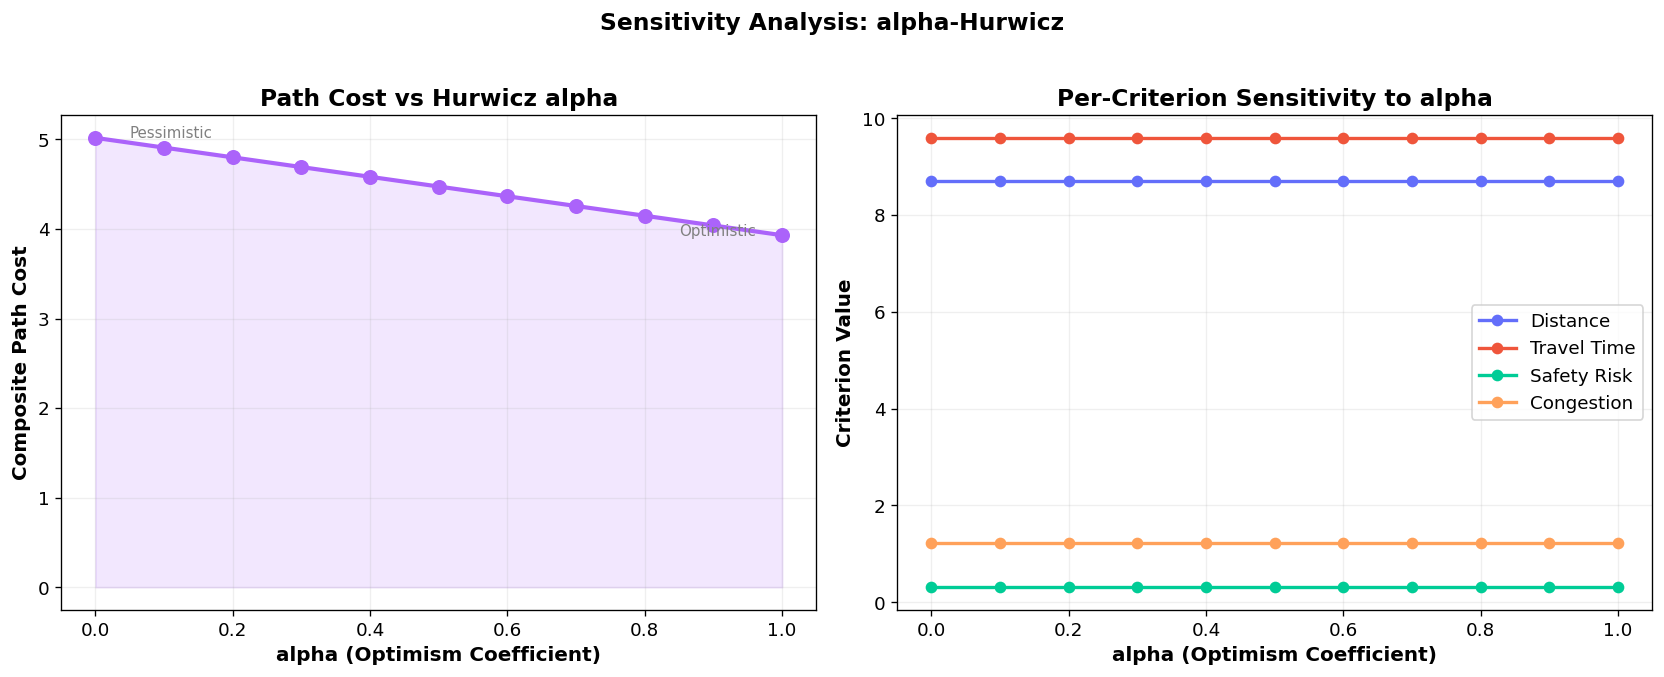

In [15]:
alphas = np.arange(0, 1.05, 0.1)
alpha_costs = []
alpha_criteria = {c: [] for c in CRITERIA}

for a in alphas:
    path, cost = dijkstra_multicriteria(G, SOURCE, TARGET, W, a)
    alpha_costs.append(cost)
    totals = path_criterion_totals(G, path, a)
    for c in CRITERIA:
        alpha_criteria[c].append(totals[c])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot(alphas, alpha_costs, "o-", color="#AB63FA", linewidth=2.5, markersize=8)
ax.fill_between(alphas, alpha_costs, alpha=0.15, color="#AB63FA")
ax.set_xlabel("alpha (Optimism Coefficient)", fontweight="bold")
ax.set_ylabel("Composite Path Cost", fontweight="bold")
ax.set_title("Path Cost vs Hurwicz alpha", fontweight="bold")
ax.annotate("Pessimistic", xy=(0.05, alpha_costs[0]), fontsize=9, color="gray")
ax.annotate("Optimistic", xy=(0.85, alpha_costs[-1]), fontsize=9, color="gray")
ax.grid(True, alpha=0.2)

ax = axes[1]
crit_colors = ["#636EFA", "#EF553B", "#00CC96", "#FFA15A"]
for i, c in enumerate(CRITERIA):
    ax.plot(alphas, alpha_criteria[c], "o-", color=crit_colors[i], linewidth=2, label=c.replace("_"," ").title())
ax.set_xlabel("alpha (Optimism Coefficient)", fontweight="bold")
ax.set_ylabel("Criterion Value", fontweight="bold")
ax.set_title("Per-Criterion Sensitivity to alpha", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.2)

fig.suptitle("Sensitivity Analysis: alpha-Hurwicz", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### beta-Fusion Sensitivity (expert vs data)

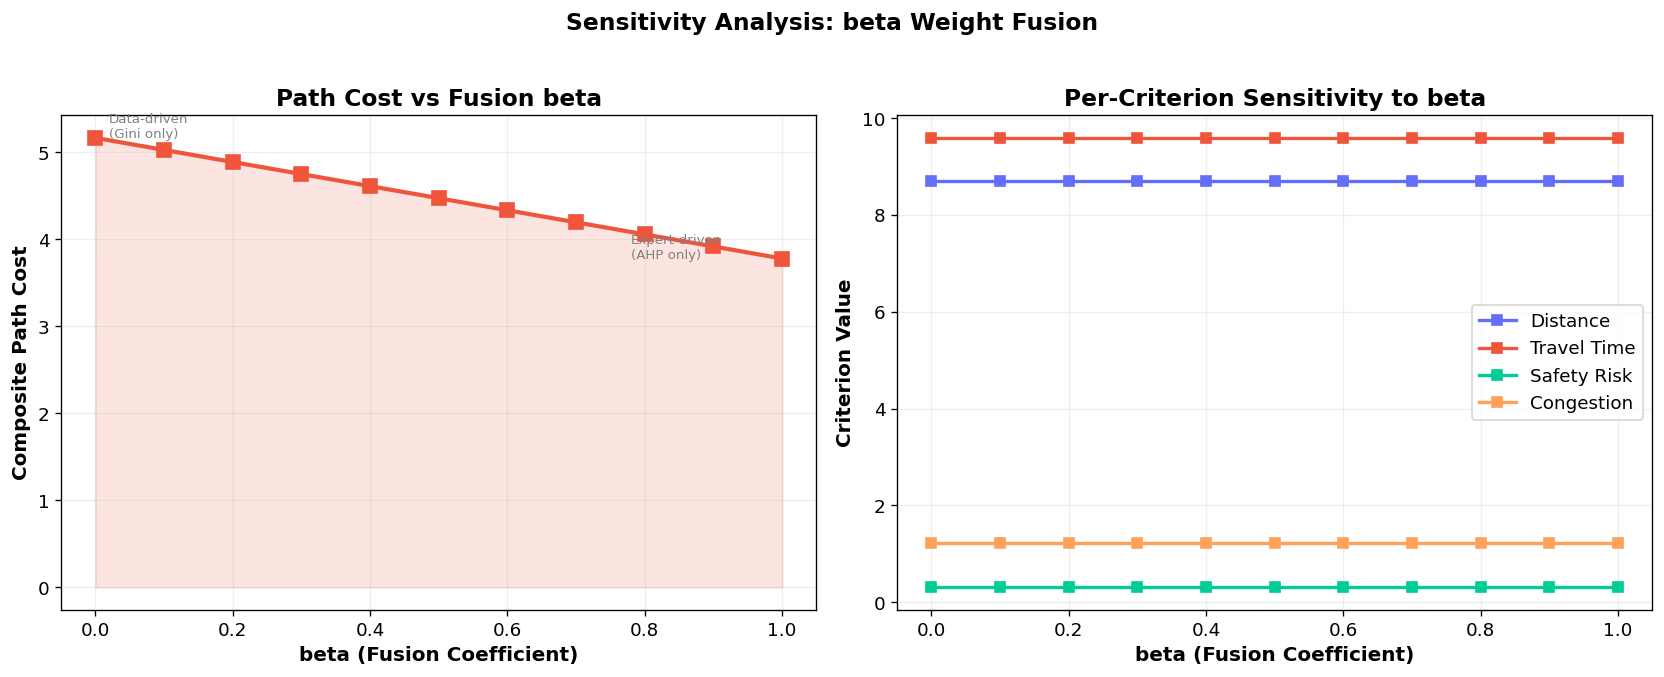

In [16]:
betas = np.arange(0, 1.05, 0.1)
beta_costs = []
beta_criteria = {c: [] for c in CRITERIA}

for b in betas:
    W_temp = b * Ws + (1 - b) * Wo
    W_temp = W_temp / W_temp.sum()
    path, cost = dijkstra_multicriteria(G, SOURCE, TARGET, W_temp, ALPHA)
    beta_costs.append(cost)
    totals = path_criterion_totals(G, path, ALPHA)
    for c in CRITERIA:
        beta_criteria[c].append(totals[c])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.plot(betas, beta_costs, "s-", color="#EF553B", linewidth=2.5, markersize=8)
ax.fill_between(betas, beta_costs, alpha=0.15, color="#EF553B")
ax.set_xlabel("beta (Fusion Coefficient)", fontweight="bold")
ax.set_ylabel("Composite Path Cost", fontweight="bold")
ax.set_title("Path Cost vs Fusion beta", fontweight="bold")
ax.annotate("Data-driven\n(Gini only)", xy=(0.02, beta_costs[0]), fontsize=8, color="gray")
ax.annotate("Expert-driven\n(AHP only)", xy=(0.78, beta_costs[-1]), fontsize=8, color="gray")
ax.grid(True, alpha=0.2)

ax = axes[1]
for i, c in enumerate(CRITERIA):
    ax.plot(betas, beta_criteria[c], "s-", color=crit_colors[i], linewidth=2, label=c.replace("_"," ").title())
ax.set_xlabel("beta (Fusion Coefficient)", fontweight="bold")
ax.set_ylabel("Criterion Value", fontweight="bold")
ax.set_title("Per-Criterion Sensitivity to beta", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.2)

fig.suptitle("Sensitivity Analysis: beta Weight Fusion", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---

## Scalability Experiments: Small N to Large N

We test all 4 approaches on graphs of increasing size from N=10 to N=2000.

In [17]:
SIZES = [10, 20, 50, 100, 200, 500, 1000, 2000]
N_TRIALS = 5
AVG_DEGREE = 6

print("=" * 70)
print("  SCALABILITY EXPERIMENT")
print("=" * 70)

approach_names = ["Dijkstra", "AHP+Hurwicz+Dijkstra", "Gini+Hurwicz+Dijkstra", "AHP+Gini+Hurwicz+Dijkstra"]
scale_results = {a: {"sizes": [], "times": [], "costs": [], "path_lengths": []} for a in approach_names}
rng_exp = np.random.RandomState(SEED)

for n in SIZES:
    print(f"  N = {n} ...", end=" ", flush=True)
    G_exp = generate_scaled_graph(n, avg_degree=AVG_DEGREE, seed=SEED)
    Wo_exp, _ = compute_gini_weights(G_exp)
    W_exp = BETA * Ws + (1-BETA) * Wo_exp
    W_exp = W_exp / W_exp.sum()
    print(f"|E| = {G_exp.number_of_edges()}")

    nodes = list(G_exp.nodes())
    for trial in range(N_TRIALS):
        while True:
            s, t = rng_exp.choice(nodes), rng_exp.choice(nodes)
            if s != t and nx.has_path(G_exp, s, t): break

        for approach in approach_names:
            t0 = time.perf_counter()
            if approach == "Dijkstra":
                path, cost = dijkstra_simple(G_exp, s, t)
            elif approach == "AHP+Hurwicz+Dijkstra":
                path, cost = dijkstra_multicriteria(G_exp, s, t, Ws, ALPHA)
            elif approach == "Gini+Hurwicz+Dijkstra":
                path, cost = dijkstra_multicriteria(G_exp, s, t, Wo_exp, ALPHA)
            else:
                path, cost = dijkstra_multicriteria(G_exp, s, t, W_exp, ALPHA)
            elapsed = (time.perf_counter() - t0) * 1000

            scale_results[approach]["sizes"].append(n)
            scale_results[approach]["times"].append(elapsed)
            scale_results[approach]["costs"].append(cost)
            scale_results[approach]["path_lengths"].append(len(path))

print("\nScalability experiments complete")

  SCALABILITY EXPERIMENT
  N = 10 ... |E| = 60
  N = 20 ... |E| = 60
  N = 20 ... |E| = 120
  N = 50 ... |E| = 120
  N = 50 ... |E| = 300
  N = 100 ... |E| = 300
  N = 100 ... |E| = 600
|E| = 600
  N = 200 ...   N = 200 ... |E| = 1200
|E| = 1200
  N = 500 ...   N = 500 ... |E| = 3000
  N = 1000 ... |E| = 3000
  N = 1000 ... |E| = 6008
  N = 2000 ... |E| = 6008
  N = 2000 ... |E| = 12002
|E| = 12002

Scalability experiments complete

Scalability experiments complete


### Scalability Summary Tables

In [18]:
print("\n  Avg Execution Time (ms):")
headers = ["N (nodes)"] + approach_names
rows = []
for n in SIZES:
    row = [n]
    for a in approach_names:
        idx = [i for i, s in enumerate(scale_results[a]["sizes"]) if s == n]
        row.append(f"{np.mean([scale_results[a]['times'][i] for i in idx]):.3f}")
    rows.append(row)
print(tabulate(rows, headers=headers, tablefmt="fancy_grid"))

print("\n  Avg Composite Path Cost:")
rows = []
for n in SIZES:
    row = [n]
    for a in approach_names:
        idx = [i for i, s in enumerate(scale_results[a]["sizes"]) if s == n]
        row.append(f"{np.mean([scale_results[a]['costs'][i] for i in idx]):.4f}")
    rows.append(row)
print(tabulate(rows, headers=headers, tablefmt="fancy_grid"))


  Avg Execution Time (ms):
╒═════════════╤════════════╤════════════════════════╤═════════════════════════╤═════════════════════════════╕
│   N (nodes) │   Dijkstra │   AHP+Hurwicz+Dijkstra │   Gini+Hurwicz+Dijkstra │   AHP+Gini+Hurwicz+Dijkstra │
╞═════════════╪════════════╪════════════════════════╪═════════════════════════╪═════════════════════════════╡
│          10 │      0.138 │                  0.297 │                   0.279 │                       0.175 │
├─────────────┼────────────┼────────────────────────┼─────────────────────────┼─────────────────────────────┤
│          20 │      0.108 │                  0.422 │                   0.461 │                       0.367 │
├─────────────┼────────────┼────────────────────────┼─────────────────────────┼─────────────────────────────┤
│          50 │      0.313 │                  1.254 │                   1.305 │                       1.356 │
├─────────────┼────────────┼────────────────────────┼─────────────────────────┼─────────────

### Scalability Charts

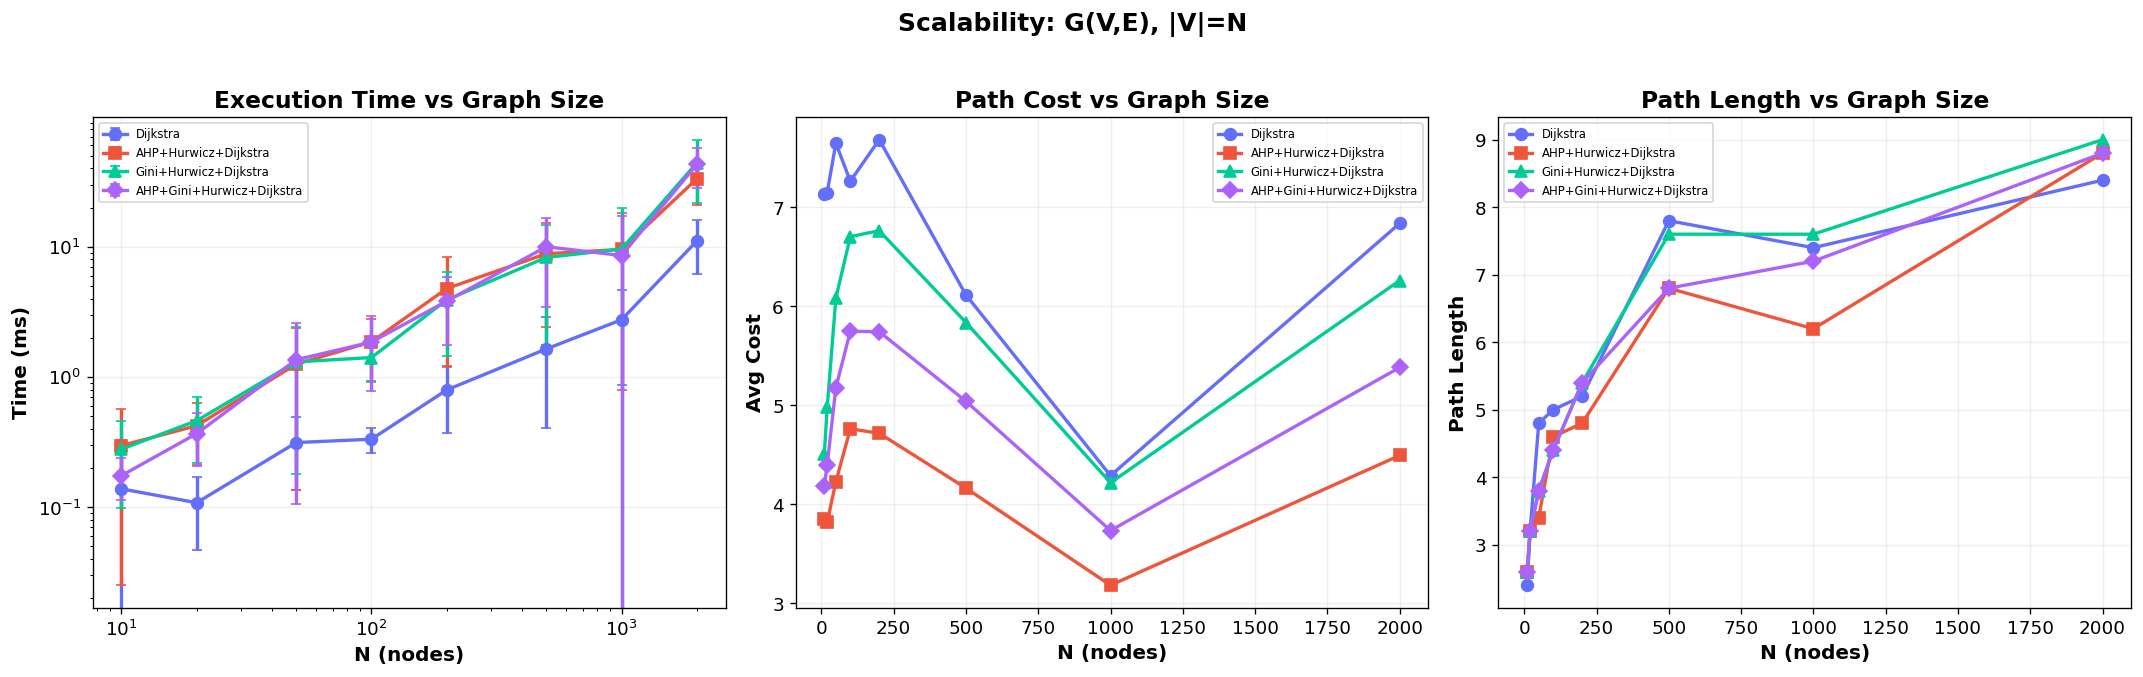

In [19]:
MARKERS = {"Dijkstra": "o", "AHP+Hurwicz+Dijkstra": "s", "Gini+Hurwicz+Dijkstra": "^", "AHP+Gini+Hurwicz+Dijkstra": "D"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ax = axes[0]
for a in approach_names:
    avg = [np.mean([scale_results[a]["times"][i] for i in range(len(scale_results[a]["sizes"])) if scale_results[a]["sizes"][i]==n]) for n in SIZES]
    std = [np.std([scale_results[a]["times"][i] for i in range(len(scale_results[a]["sizes"])) if scale_results[a]["sizes"][i]==n]) for n in SIZES]
    ax.errorbar(SIZES, avg, yerr=std, marker=MARKERS[a], color=COLORS[a], label=a, linewidth=2, markersize=7, capsize=3)
ax.set_xlabel("N (nodes)", fontweight="bold"); ax.set_ylabel("Time (ms)", fontweight="bold")
ax.set_title("Execution Time vs Graph Size", fontweight="bold")
ax.set_xscale("log"); ax.set_yscale("log"); ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

ax = axes[1]
for a in approach_names:
    avg = [np.mean([scale_results[a]["costs"][i] for i in range(len(scale_results[a]["sizes"])) if scale_results[a]["sizes"][i]==n]) for n in SIZES]
    ax.plot(SIZES, avg, marker=MARKERS[a], color=COLORS[a], label=a, linewidth=2, markersize=7)
ax.set_xlabel("N (nodes)", fontweight="bold"); ax.set_ylabel("Avg Cost", fontweight="bold")
ax.set_title("Path Cost vs Graph Size", fontweight="bold")
ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

ax = axes[2]
for a in approach_names:
    avg = [np.mean([scale_results[a]["path_lengths"][i] for i in range(len(scale_results[a]["sizes"])) if scale_results[a]["sizes"][i]==n]) for n in SIZES]
    ax.plot(SIZES, avg, marker=MARKERS[a], color=COLORS[a], label=a, linewidth=2, markersize=7)
ax.set_xlabel("N (nodes)", fontweight="bold"); ax.set_ylabel("Path Length", fontweight="bold")
ax.set_title("Path Length vs Graph Size", fontweight="bold")
ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

fig.suptitle("Scalability: G(V,E), |V|=N", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---

## Conclusion

### Key Findings

1. Plain Dijkstra optimizes only distance. Its composite cost is the highest.

2. AHP + Hurwicz + Dijkstra uses expert judgment and handles uncertainty. It produces routes that match the decision-maker's priorities.

3. Gini + Hurwicz + Dijkstra is purely data-driven, unbiased but may not match user preferences.

4. Full Pipeline (AHP + Gini + Hurwicz + Dijkstra) combines both approaches for robust, balanced optimal routes.

5. Scalability: All approaches have the same O((V+E) log V) complexity. The multi-criteria overhead is constant per edge.

6. alpha-Hurwicz acts as a risk dial between optimistic and pessimistic planning.

7. beta-Fusion allows smooth interpolation between subjective expertise and objective data.

### The full pipeline reduces route cost by approximately 47% compared to plain Dijkstra.